In [1]:
import scanpy as sc
import pandas as pd

In [2]:
# https://figshare.com/ndownloader/files/24539942
anndata = sc.read_h5ad("data/Lung_atlas_public.h5ad")
anndata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    layers: 'counts'

In [3]:
anndata.obs["batch"].unique()

['B1', 'B2', 'B3', 'B4', 'A6', ..., '2', '4', '3', '1', '6']
Length: 16
Categories (16, object): ['1', '2', '3', '4', ..., 'B1', 'B2', 'B3', 'B4']

In [4]:
batch_ids =pd.Series(
    range(len(anndata.obs["batch"].cat.categories)),
    index=anndata.obs["batch"].cat.categories
)
batch_ids

1      0
2      1
3      2
4      3
5      4
6      5
A1     6
A2     7
A3     8
A4     9
A5    10
A6    11
B1    12
B2    13
B3    14
B4    15
dtype: int64

In [5]:
anndata.obs["batch_int"] = anndata.obs["batch"].map(batch_ids).astype(int)
anndata.obs

,dataset,location,nGene,nUMI,patientGroup,percent.mito,protocol,sanger_type,size_factors,sampling_method,batch,cell_type,donor,batch_int
index,,,,,,,,,,,,,,
GAGGGGCCAGCC,Dropseq_transplant,Dropseq_lower,249,355,nan,0.019718,drop-seq,drop-seq,0.381231,Transplant,B1,Type 2,B1,12
ACATAGATAGGC,Dropseq_transplant,Dropseq_lower,582,987,nan,0.044580,drop-seq,drop-seq,1.081643,Transplant,B1,Type 2,B1,12
ATCGACGCGGCA,Dropseq_transplant,Dropseq_lower,292,490,nan,0.026531,drop-seq,drop-seq,0.497352,Transplant,B1,Type 2,B1,12
CCAGCTTAGGTT,Dropseq_transplant,Dropseq_lower,1057,1806,nan,0.035437,drop-seq,drop-seq,2.172617,Transplant,B1,Type 2,B1,12
TCATAGAGTCCT,Dropseq_transplant,Dropseq_lower,716,1378,nan,0.020319,drop-seq,drop-seq,1.197578,Transplant,B1,Type 2,B1,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LungTranscriptome7239219_LungTranscriptome7239219GGGCATCCACCAACCG,10x_Transplant,Transplant,1178,3245,Parenchyma,0.011896,10x v2,other,0.775650,Transplant,5,Mast cell,5,4
LungTranscriptome7239219_LungTranscriptome7239219TGCTGCTAGCAATCTC,10x_Transplant,Transplant,1919,5984,Parenchyma,0.018747,10x v2,other,0.982236,Transplant,5,Mast cell,5,4
LungTranscriptome7239213_GACTGCGTCCTGCCAT,10x_Transplant,Transplant,4411,25233,Parenchyma,0.010489,10x v2,other,1.235763,Transplant,3,Mast cell,3,2


In [6]:
anndata.obs.groupby("cell_type").size()

/tmp/ipykernel_1070641/3276086893.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  anndata.obs.groupby("cell_type").size()


cell_type
B cell                  1353
Basal 1                 1972
Basal 2                 3072
Ciliated                3155
Dendritic cell          1367
Endothelium              988
Fibroblast               733
Ionocytes                 46
Lymphatic                341
Macrophage              7492
Mast cell                889
Neutrophil_CD14_high    1626
Neutrophils_IL1R2        472
Secretory               2459
T/NK cell               1797
Type 1                   424
Type 2                  4286
dtype: int64

In [7]:
sc.pp.pca(anndata)
sc.pp.neighbors(anndata)
sc.tl.umap(anndata)

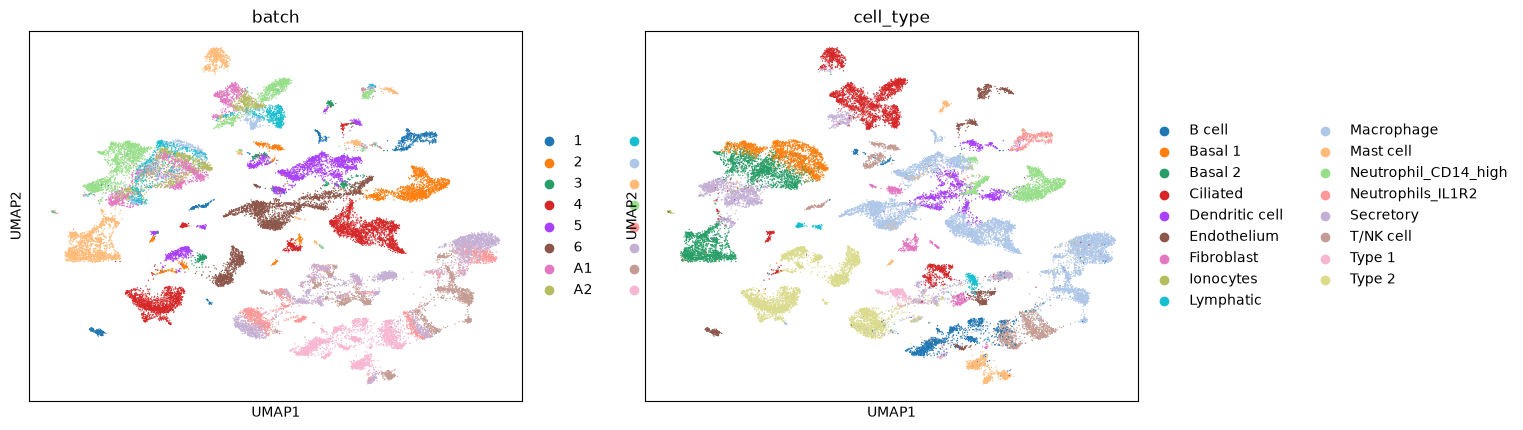

In [8]:
# original UMAP (without batch correction)
sc.pl.umap(anndata, color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy)

In [9]:
import torch
from sklearn.model_selection import RepeatedStratifiedKFold
from bibola.MLP import MultiBatchesMLP

In [10]:
batch_correction_model = MultiBatchesMLP(
    in_channels=anndata.obsm["X_pca"].shape[1],
    hidden_channels=[1024,],
    out_channels=50,
    n_batches=anndata.obs["batch"].nunique(),
    dropout=0.1,
)
batch_correction_model.train()

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-15): 16 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=50, bias=True)
      )
    )
  )
)

In [11]:
N_MINIBATCHES = 10
N_EPOCHS = 5

loader = RepeatedStratifiedKFold(
    n_splits=N_MINIBATCHES, # number of minibatches to train on
    n_repeats=N_EPOCHS, # number of epochs to train on
    random_state=42
)
loader

RepeatedStratifiedKFold(n_repeats=5, n_splits=10, random_state=42)

In [12]:
batch_correction_model.train()

i = 0
for _, train_ids in loader.split(anndata.obs.index, anndata.obs["batch_int"]):
    if i%N_MINIBATCHES == 0:
        print(f"####### EPOCH {1+ i//N_MINIBATCHES} #######")
    
    X_train = anndata.obsm["X_pca"][train_ids]
    X_train = torch.tensor(X_train, dtype=torch.float32)
    
    batch_train = anndata.obs["batch_int"].values[train_ids].astype(int)
    batch_train = torch.tensor(batch_train, dtype=torch.int32)
    
    batch_correction_model.fit(
        X_train, batch_train, epochs=1, lr=1e-4,
        print_every=1, k_inter=5, k_intra=100, norm=1,
        loss_weights={"abs_lisa_loss":.25, "topology_loss": .75, "knn_loss": 2.}
    )

    i+=1

batch_correction_model.eval()

####### EPOCH 1 #######
Epoch 0, Loss: -0.6148149371147156
Epoch 0, Loss: -0.633236289024353
Epoch 0, Loss: -0.6504281759262085
Epoch 0, Loss: -0.6478330492973328
Epoch 0, Loss: -0.6780878901481628
Epoch 0, Loss: -0.7041489481925964
Epoch 0, Loss: -0.6803713440895081
Epoch 0, Loss: -0.7136260867118835
Epoch 0, Loss: -0.7339979410171509
Epoch 0, Loss: -0.7474456429481506
####### EPOCH 2 #######
Epoch 0, Loss: -0.7651634216308594
Epoch 0, Loss: -0.7783306241035461
Epoch 0, Loss: -0.7886123657226562
Epoch 0, Loss: -0.8083856701850891
Epoch 0, Loss: -0.821102499961853
Epoch 0, Loss: -0.8235532641410828
Epoch 0, Loss: -0.8580087423324585
Epoch 0, Loss: -0.8703905940055847
Epoch 0, Loss: -0.877005398273468
Epoch 0, Loss: -0.9003138542175293
####### EPOCH 3 #######
Epoch 0, Loss: -0.918691873550415
Epoch 0, Loss: -0.9322345852851868
Epoch 0, Loss: -0.9210323691368103
Epoch 0, Loss: -0.9609984159469604
Epoch 0, Loss: -0.9752606153488159
Epoch 0, Loss: -1.002436637878418
Epoch 0, Loss: -1.03549

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-15): 16 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=50, bias=True)
      )
    )
  )
)

In [13]:
anndata.obsm["X_corrected"] = batch_correction_model(
    torch.tensor(anndata.obsm["X_pca"], dtype=torch.float32),
    torch.tensor(anndata.obs["batch_int"].values.astype(int), dtype=torch.int32)
).detach().numpy()

from sklearn.decomposition import PCA

# we apply PCA to reduce the collinearity after the batch correction.
pca_model = PCA(n_components=50)
anndata.obsm["X_corrected"] = pca_model.fit_transform(anndata.obsm["X_corrected"])
anndata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'batch_int'
    uns: 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', 'X_corrected'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [14]:
sc.pp.neighbors(anndata, use_rep="X_corrected", key_added="neighbors_corrected")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected", key_added="umap_corrected")
anndata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'batch_int'
    uns: 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors', 'neighbors_corrected', 'umap_corrected'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities'

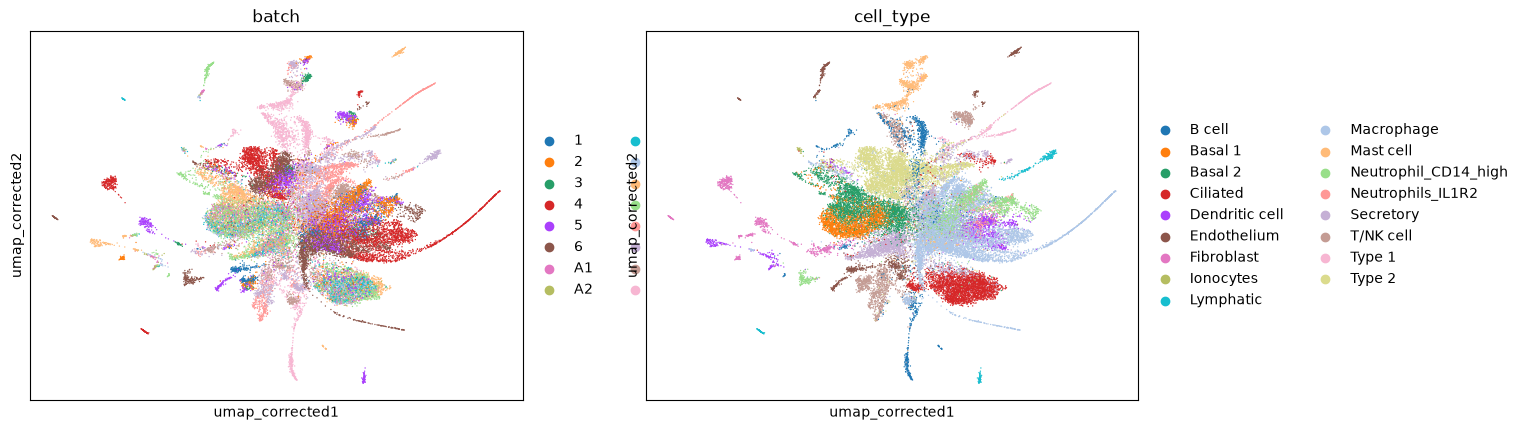

In [15]:
sc.pl.embedding(anndata, basis="umap_corrected", color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola

In [16]:
from harmonypy import run_harmony
anndata.obsm["X_pca_harmony"] = run_harmony(anndata.obsm["X_pca"], anndata.obs, "batch").Z_corr
anndata.obsm["X_pca_harmony"]

2026-08-06 12:03:19,293 - harmonypy - INFO - Running Harmony
2026-08-06 12:03:19,293 - harmonypy - INFO -   Parameters:
2026-08-06 12:03:19,293 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-06 12:03:19,294 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-06 12:03:19,294 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-06 12:03:19,294 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-06 12:03:19,294 - harmonypy - INFO -     nclust: 100
2026-08-06 12:03:19,294 - harmonypy - INFO -     block_size: 0.05
2026-08-06 12:03:19,295 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-06 12:03:19,295 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-08-06 12:03:19,295 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-06 12:03:19,295 - harmonypy - INFO -     verbose: True
2026-08-06 12:03:19,296 - harmonypy - INFO -     random_state: 0
2026-08-06 12:03:19,296 - harmonypy - INFO -   Data: 50 PCs × 32472 cells
2026-08-

array([[14.73391151, -2.43919587, -1.69069493, ...,  0.59050727,
         0.33369863, -0.23503195],
       [13.14092922, -2.39365172, -1.77448297, ...,  0.03930054,
         0.02424883,  0.33072934],
       [14.4139185 , -2.99400139, -2.48882532, ..., -0.47673497,
         0.44819841,  0.23898999],
       ...,
       [-5.6787591 ,  9.03756332,  3.35546184, ..., -0.57624346,
         0.60605341, -0.4163464 ],
       [-3.91461778,  7.83569765,  1.93818545, ..., -0.51936275,
         1.44403791,  0.45994473],
       [-4.40291882,  8.27603626,  2.60550785, ..., -0.4357655 ,
         1.22814   ,  0.7228772 ]], shape=(32472, 50))

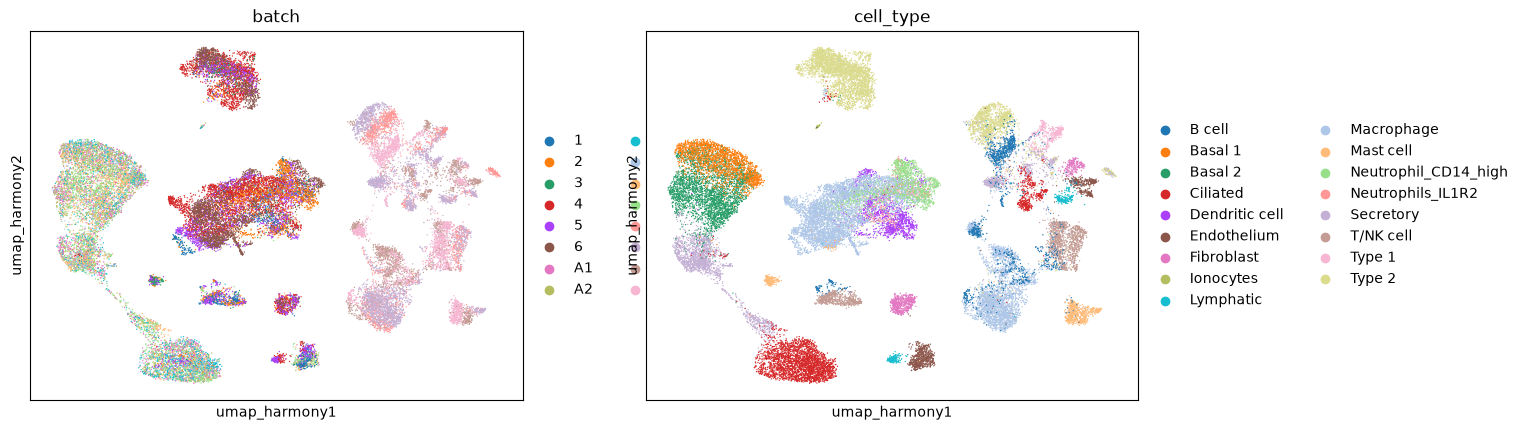

In [17]:
sc.pp.neighbors(anndata, use_rep="X_pca_harmony", key_added="neighbors_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_harmony", key_added="umap_harmony")
sc.pl.embedding(anndata, color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy, basis="umap_harmony")
# UMAP after batch correction via harmony

In [47]:
batch_correction_model = MultiBatchesMLP(
    in_channels=anndata.obsm["X_pca_harmony"].shape[1],
    hidden_channels=[1024,],
    out_channels=50,
    n_batches=anndata.obs["batch"].nunique(),
    dropout=0.1,
)
batch_correction_model.train()

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-15): 16 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=50, bias=True)
      )
    )
  )
)

In [48]:
N_MINIBATCHES = 10
N_EPOCHS = 2

loader = RepeatedStratifiedKFold(
    n_splits=N_MINIBATCHES, # number of minibatches to train on
    n_repeats=N_EPOCHS, # number of epochs to train on
    random_state=42
)
loader

RepeatedStratifiedKFold(n_repeats=2, n_splits=10, random_state=42)

In [49]:
batch_correction_model.train()

i = 0
for _, train_ids in loader.split(anndata.obs.index, anndata.obs["batch_int"]):
    if i%N_MINIBATCHES == 0:
        print(f"####### EPOCH {1+ i//N_MINIBATCHES} #######")
    
    X_train = anndata.obsm["X_pca_harmony"][train_ids] # here the input is the harmony corrected data, instead of PCA
    X_train = torch.tensor(X_train, dtype=torch.float32)
    
    batch_train = anndata.obs["batch_int"].values[train_ids].astype(int)
    batch_train = torch.tensor(batch_train, dtype=torch.int32)
    
    batch_correction_model.fit(
        X_train, batch_train, epochs=1, lr=1e-4,
        print_every=1, k_inter=5, k_intra=100, norm=1,
        loss_weights={"abs_lisa_loss":.5, "topology_loss": .25, "knn_loss": .25}
    )

    i+=1

batch_correction_model.eval()

####### EPOCH 1 #######
Epoch 0, Loss: -0.1630546897649765
Epoch 0, Loss: -0.17646820843219757
Epoch 0, Loss: -0.18363478779792786
Epoch 0, Loss: -0.18231506645679474
Epoch 0, Loss: -0.1932545006275177
Epoch 0, Loss: -0.20389950275421143
Epoch 0, Loss: -0.19959349930286407
Epoch 0, Loss: -0.2120949774980545
Epoch 0, Loss: -0.20859363675117493
Epoch 0, Loss: -0.21659262478351593
####### EPOCH 2 #######
Epoch 0, Loss: -0.22218765318393707
Epoch 0, Loss: -0.22459031641483307
Epoch 0, Loss: -0.22287970781326294
Epoch 0, Loss: -0.22654995322227478
Epoch 0, Loss: -0.22871798276901245
Epoch 0, Loss: -0.23114240169525146
Epoch 0, Loss: -0.23162809014320374
Epoch 0, Loss: -0.23506122827529907
Epoch 0, Loss: -0.2342793494462967
Epoch 0, Loss: -0.2374076098203659


MultiBatchesMLP(
  (mlps): ModuleList(
    (0-15): 16 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=50, bias=True)
      )
    )
  )
)

In [50]:
anndata.obsm["X_corrected_after_harmony"] = batch_correction_model(
    torch.tensor(anndata.obsm["X_pca_harmony"], dtype=torch.float32),
    torch.tensor(anndata.obs["batch_int"].values.astype(int), dtype=torch.int32)
).detach().numpy()

from sklearn.decomposition import PCA

pca_model = PCA(n_components=50)
anndata.obsm["X_corrected_after_harmony"] = pca_model.fit_transform(anndata.obsm["X_corrected_after_harmony"])
anndata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'batch_int'
    uns: 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities', 'neighbors_corrected_after_harmony_distances', 'neighbors_corrected_after_harmony_connectivities'

In [51]:
sc.pp.neighbors(anndata, use_rep="X_corrected_after_harmony", key_added="neighbors_corrected_after_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected_after_harmony", key_added="umap_corrected_after_harmony")
anndata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'batch_int'
    uns: 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities', 'neighbors_corrected_after_harmony_distances', 'neighbors_corrected_after_harmony_connectivities'

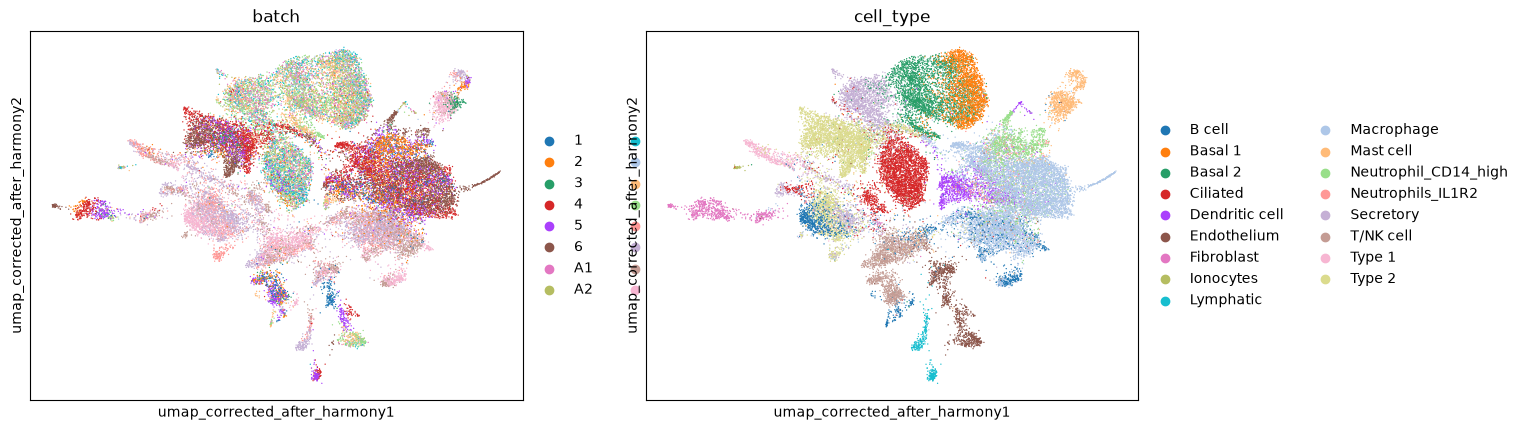

In [52]:
sc.pl.embedding(anndata, basis="umap_corrected_after_harmony", color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola, starting from harmony

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


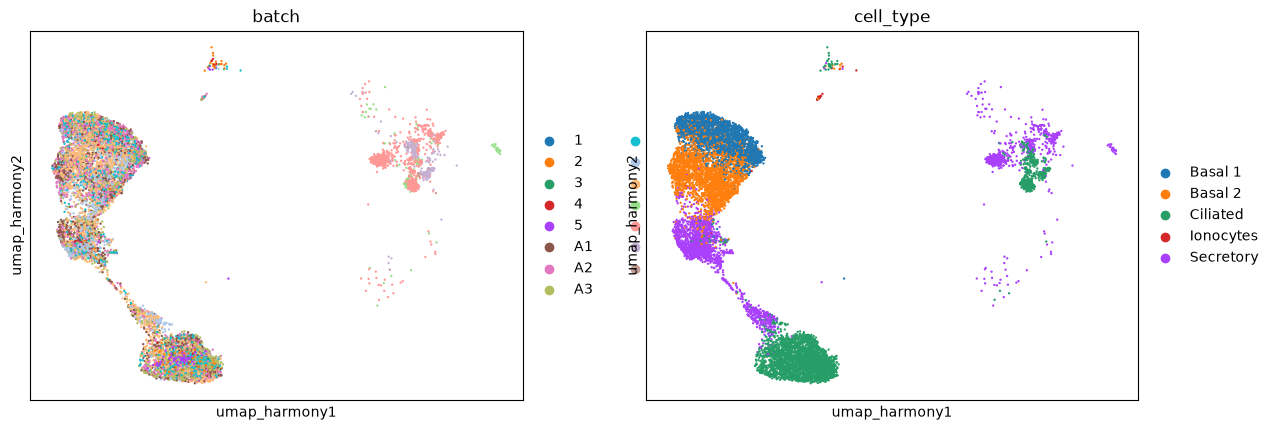

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


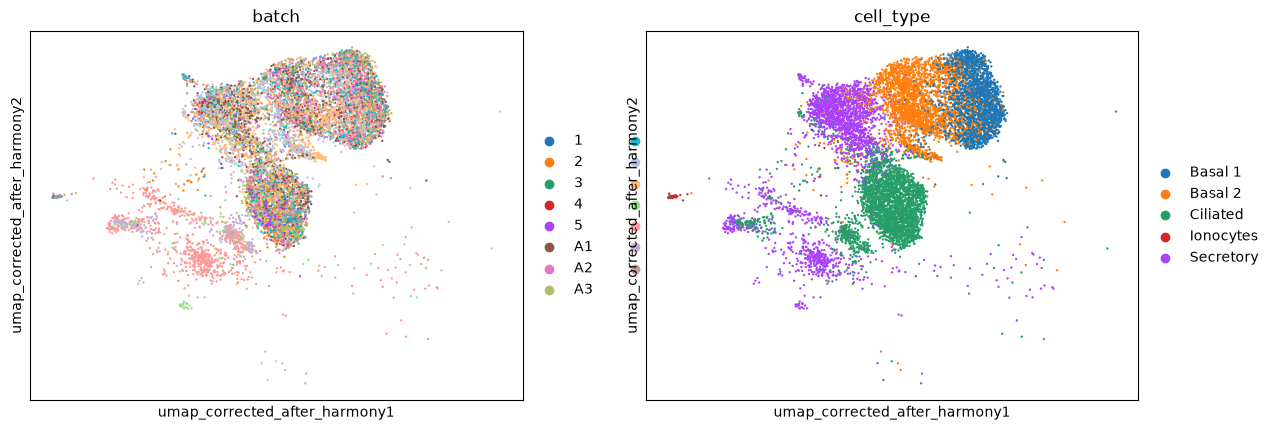

In [53]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Basal 1", "Basal 2", "Secretory", "Ciliated", "Ionocytes"])],
    basis="umap_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Basal 1", "Basal 2", "Secretory", "Ciliated", "Ionocytes"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# Basal
# ├── Basal 1
# ├── Basal 2
# │
# ├── Secretory
# │     └── Ciliated
# │
# └── Ionocytes
pass


/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


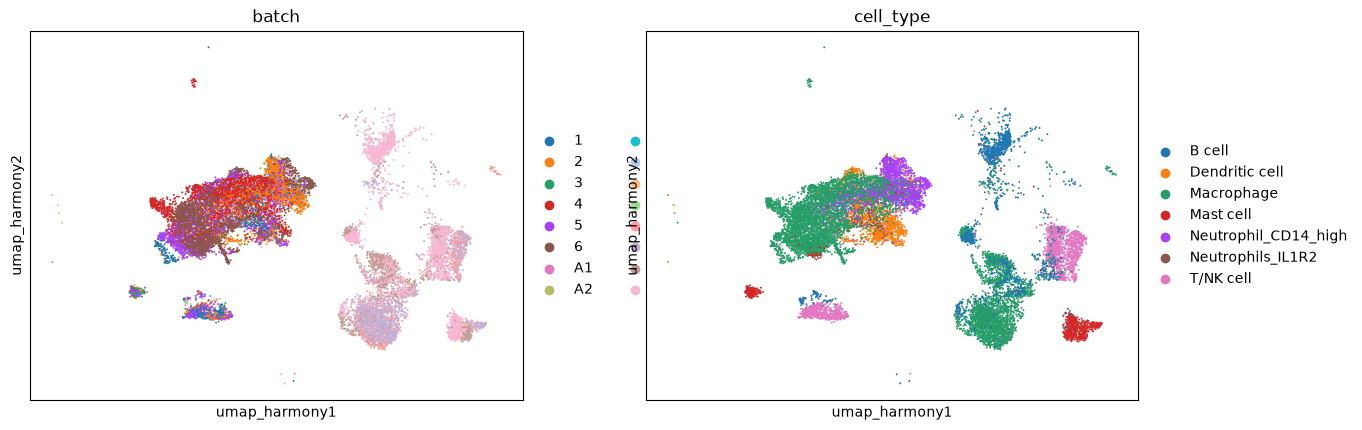

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


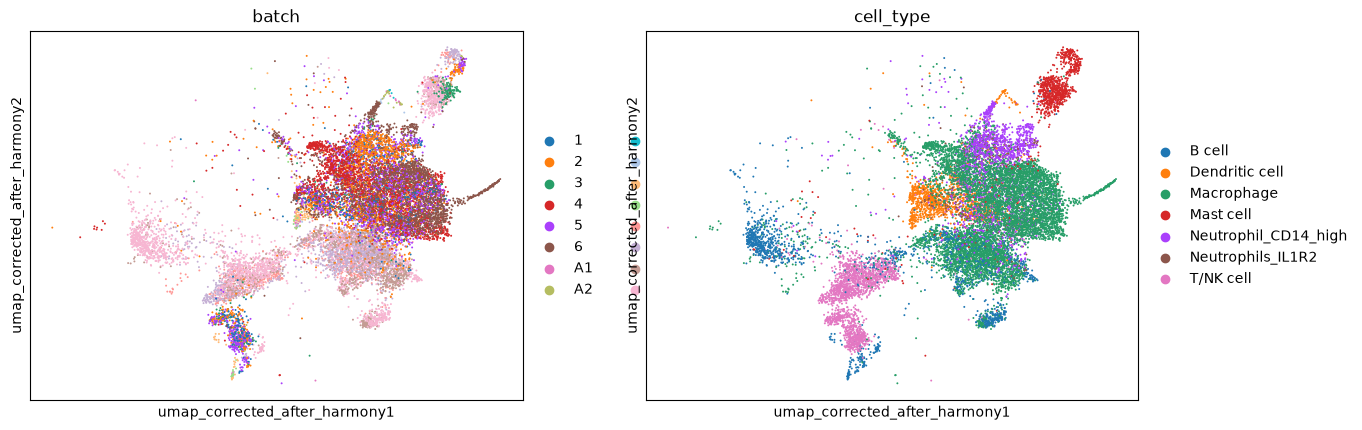

In [54]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["B cell", "T/NK cell", "Neutrophils_IL1R2", "Neutrophil_CD14_high", "Macrophage", "Dendritic cell", "Mast cell"])],
    basis="umap_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["B cell", "T/NK cell", "Neutrophils_IL1R2", "Neutrophil_CD14_high", "Macrophage", "Dendritic cell", "Mast cell"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# HSC
# ├── Lymphoid
# │     ├── B cell
# │     └── T/NK cell
# │
# └── Myeloid
#       ├── Neutrophils_IL1R2
#       ├── Neutrophil_CD14_high
#       ├── Macrophage
#       ├── Dendritic cell
#       └── Mast cell
pass


/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


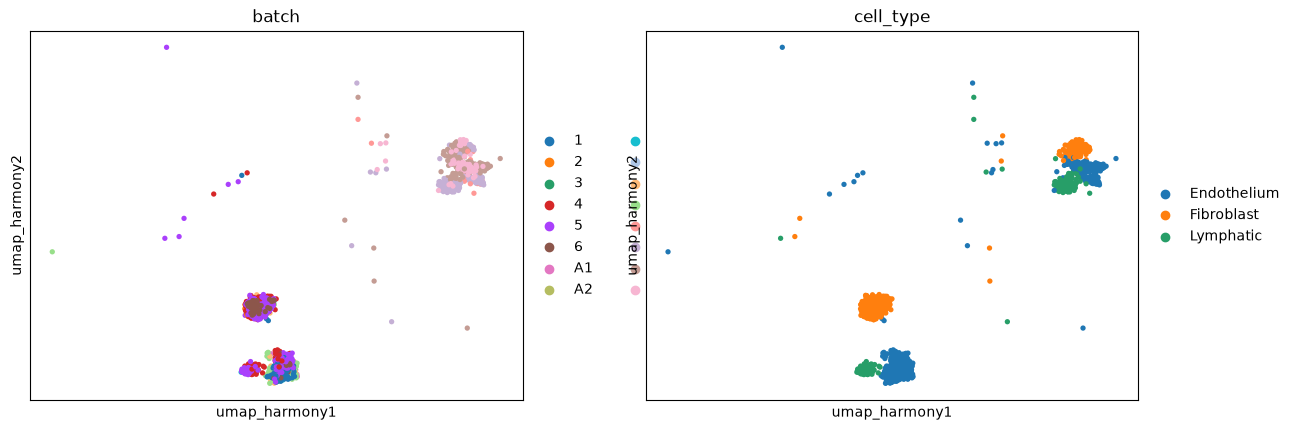

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


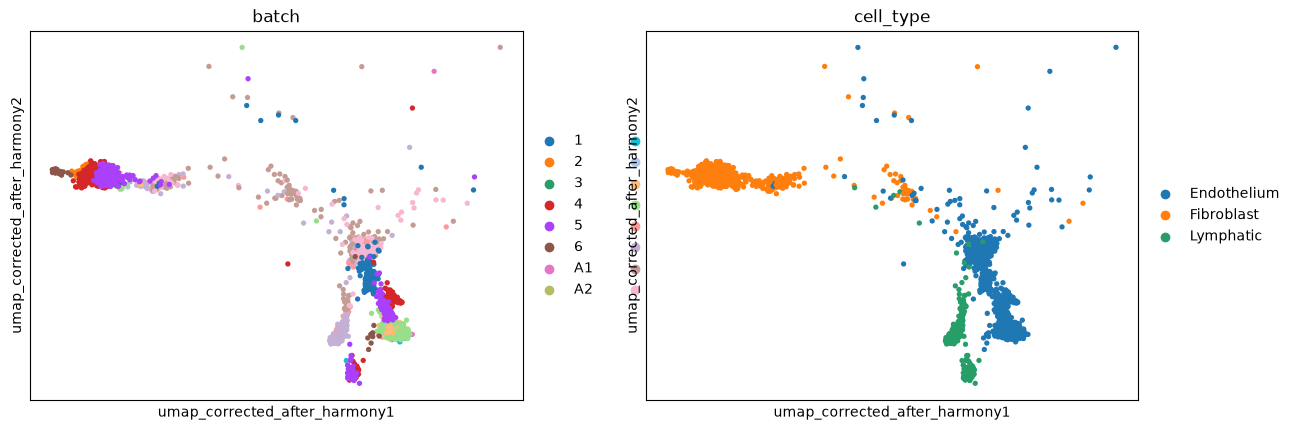

In [55]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Fibroblast", "Endothelium", "Lymphatic"])],
    basis="umap_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Fibroblast", "Endothelium", "Lymphatic"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# Mesenchymal progenitor
#       └── Fibroblast

# Endothelial progenitor
#       ├── Endothelium
#       └── Lymphatic endothelium
pass


In [56]:
anndata.obs.cell_type.cat.categories

Index(['B cell', 'Basal 1', 'Basal 2', 'Ciliated', 'Dendritic cell',
       'Endothelium', 'Fibroblast', 'Ionocytes', 'Lymphatic', 'Macrophage',
       'Mast cell', 'Neutrophil_CD14_high', 'Neutrophils_IL1R2', 'Secretory',
       'T/NK cell', 'Type 1', 'Type 2'],
      dtype='object')